In [120]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas import ExcelWriter
from pandas import ExcelFile
from sklearn.model_selection import train_test_split
from sklearn import preprocessing

In [54]:
address='/Users/Ali/Desktop/Data_Sima/StykuDataSet.csv'
SUP=pd.read_csv(address,encoding = "ISO-8859-1")

#SUP.shape

feat1=['TOTAL_FAT','TOTAL_LEAN','bmi_calculated','BMI','age','race','SEX','TotalVolume', 'rArmVolume','lArmVolume', 'rLegVolume', 'lLegVolume', 'headVolume', 'trunkVolume',
       'Chest circ', 'waist circ', 'hip circ', 'rThighGirth', 'lThighGirth',
       'rCalfCirc', 'lCalfCirc', 'rWristGirth', 'lWristGirth', 'rForearm',
       'lForearmGirth', 'rbicepGirth', 'lBicepGirth', 'rAnkle', 'Lankle',
       'LarmLength', 'RArmLength', 'CollarScalp', 'TrunkLength', 'lLegLength',
       'rLegLength', 'crotchHeight', 'Chest circ A_B', 'waist circ A_B',
       'hip circ A_B', 'rThighGirth A_B', 'lThighGirth A_B', 'rCalfCirc A_B',
       'lCalfCirc A_B', 'rWristGirth A_B', 'lWristGirth A_B', 'rForearm A_B',
       'lForearmGirth A_B', 'rbicepGirth A_B', 'lBicepGirth A_B', 'rAnkle A_B',
       'Lankle A_B', 'SA_total', 'SA_lArm', 'SA_rArm', 'SA_head', 'SA_lLeg',
       'SA_rLeg', 'SA_trunk']

SUP1=SUP[feat1]
print(SUP1.shape)
SUP1.head()


(535, 58)


,TOTAL_FAT,TOTAL_LEAN,bmi_calculated,BMI,age,race,SEX,TotalVolume,rArmVolume,lArmVolume,...,lBicepGirth A_B,rAnkle A_B,Lankle A_B,SA_total,SA_lArm,SA_rArm,SA_head,SA_lLeg,SA_rLeg,SA_trunk
0,6087.593068,14801.86054,27.854844,27.839429,27.0,4.0,M,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,7101.949856,12460.91465,26.941290,26.959457,44.0,0.0,F,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,22.736930,22.736930,27.0,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4895.588292,13996.14950,26.914735,27.916079,54.0,0.0,M,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,28.040786,28.040786,57.0,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [59]:
#SUP1.SEX.isna().sum()
SUP2=SUP1.dropna()
print(SUP2.shape)

(247, 58)


In [86]:
feat2=['TOTAL_FAT','BMI','age','race','TotalVolume', 'rArmVolume','lArmVolume', 'rLegVolume', 'lLegVolume', 'headVolume', 'trunkVolume',
       'Chest circ', 'waist circ', 'hip circ', 'rThighGirth', 'lThighGirth',
       'rCalfCirc', 'lCalfCirc', 'rWristGirth', 'lWristGirth', 'rForearm',
       'lForearmGirth', 'rbicepGirth', 'lBicepGirth', 'rAnkle', 'Lankle',
       'LarmLength', 'RArmLength', 'CollarScalp', 'TrunkLength', 'lLegLength',
       'rLegLength', 'crotchHeight', 'Chest circ A_B', 'waist circ A_B',
       'hip circ A_B', 'rThighGirth A_B', 'lThighGirth A_B', 'rCalfCirc A_B',
       'lCalfCirc A_B', 'rWristGirth A_B', 'lWristGirth A_B', 'rForearm A_B',
       'lForearmGirth A_B', 'rbicepGirth A_B', 'lBicepGirth A_B', 'rAnkle A_B',
       'Lankle A_B', 'SA_total', 'SA_lArm', 'SA_rArm', 'SA_head', 'SA_lLeg',
       'SA_rLeg', 'SA_trunk']
SUP3=SUP2[feat2]

SUP3['ArmVolume']=SUP3[['rArmVolume','lArmVolume']].mean(axis=1)
SUP3['LegVolume']=SUP3[['rLegVolume','lLegVolume']].mean(axis=1)
SUP3['ThighGirth']=SUP3[['rThighGirth', 'lThighGirth']].mean(axis=1)
SUP3['CalfCirc']=SUP3[['rCalfCirc', 'lCalfCirc']].mean(axis=1)
SUP3['WristGirth']=SUP3[['rWristGirth', 'lWristGirth']].mean(axis=1)
SUP3['ForearmGirth']=SUP3[['rForearm','lForearmGirth']].mean(axis=1)
SUP3['BicepGirth']=SUP3[['rbicepGirth', 'lBicepGirth']].mean(axis=1)
SUP3['Ankle']=SUP3[['rAnkle', 'Lankle']].mean(axis=1)
SUP3['ArmLength']=SUP3[['LarmLength', 'RArmLength']].mean(axis=1)
SUP3['LegLength']=SUP3[['lLegLength', 'rLegLength']].mean(axis=1)
SUP3['ThighGirth A_B']=SUP3[['rThighGirth A_B', 'lThighGirth A_B']].mean(axis=1)
SUP3['CalfCirc A_B']=SUP3[['rCalfCirc A_B', 'lCalfCirc A_B']].mean(axis=1)
SUP3['WristGirth A_B']=SUP3[['rWristGirth A_B', 'lWristGirth A_B']].mean(axis=1)
SUP3['ForearmGirth A_B']=SUP3[['rForearm A_B','lForearmGirth A_B']].mean(axis=1)
SUP3['BicepGirth A_B']=SUP3[['rbicepGirth A_B', 'lBicepGirth A_B']].mean(axis=1)
SUP3['Ankle A_B']=SUP3[['rAnkle A_B', 'Lankle A_B']].mean(axis=1)
SUP3['SA_Arm']=SUP3[['SA_lArm', 'SA_rArm']].mean(axis=1)
SUP3['SA_Leg']=SUP3[['SA_lLeg', 'SA_rLeg']].mean(axis=1)

SUP3.shape


/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  
/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  from ipykernel import kernelapp as app


(247, 73)

In [109]:
feat3=['TOTAL_FAT','BMI','age','race','TotalVolume', 'ArmVolume', 'LegVolume', 'headVolume', 'trunkVolume',
       'Chest circ', 'waist circ', 'hip circ', 'ThighGirth','CalfCirc', 'WristGirth',
       'ForearmGirth','BicepGirth', 'Ankle','ArmLength', 'CollarScalp', 'TrunkLength', 'LegLength',
       'crotchHeight', 'Chest circ A_B', 'waist circ A_B','hip circ A_B', 'ThighGirth A_B', 'CalfCirc A_B',
       'WristGirth A_B','ForearmGirth A_B', 'BicepGirth A_B', 'Ankle A_B',
       'SA_total', 'SA_Arm', 'SA_head', 'SA_Leg','SA_trunk']
SUP4=SUP3[feat3]
SUP4.drop([SUP4.headVolume.idxmax()],inplace=True)
SUP4.shape
corr=SUP4.corr()

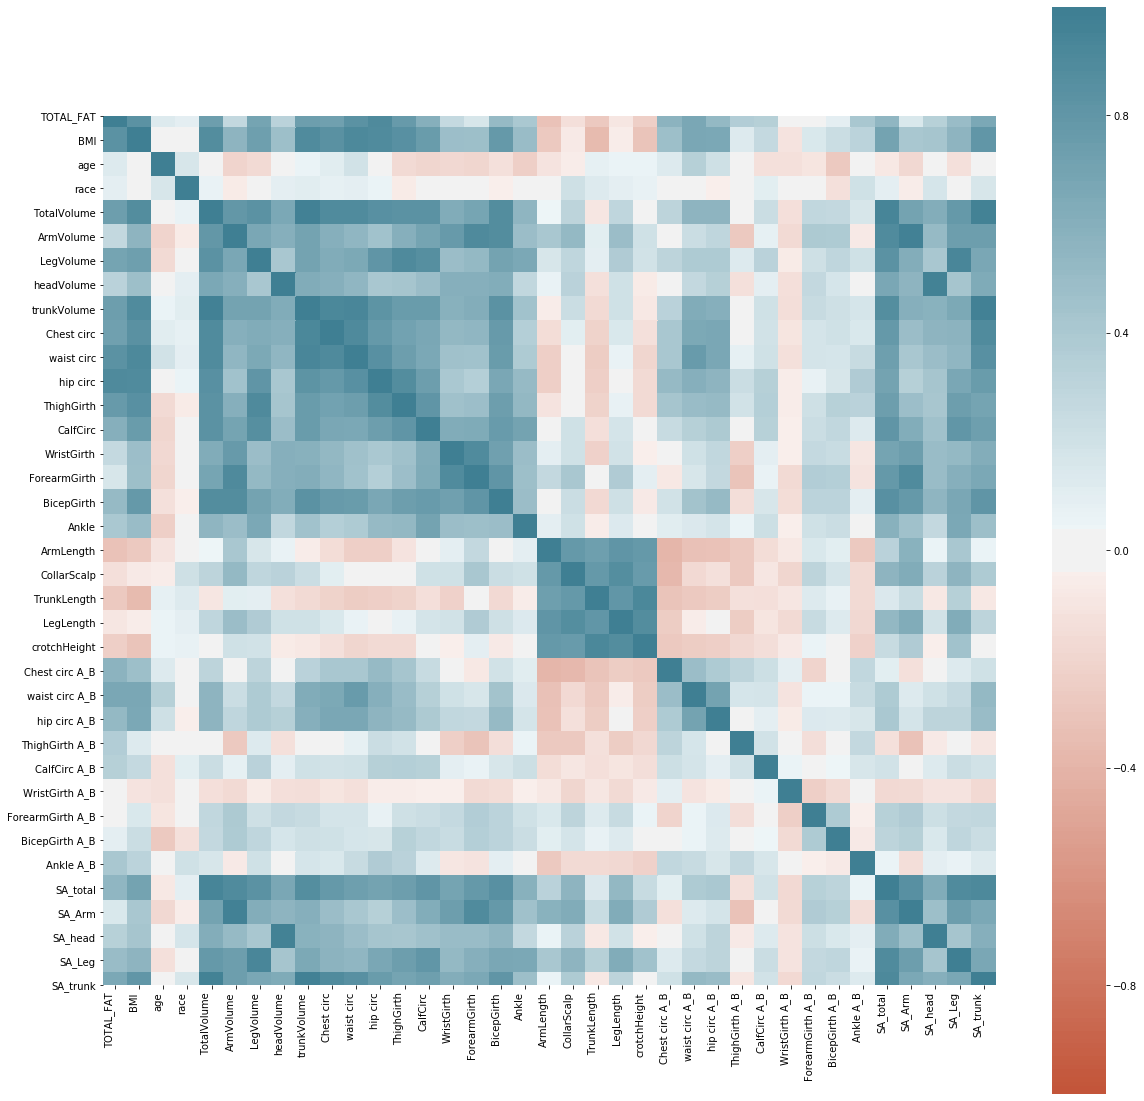

In [110]:
    fig, ax = plt.subplots(figsize=(20,20))

ax = sns.heatmap(
    corr, 
    vmin=-1, vmax=1, center=0,
    cmap=sns.diverging_palette(20, 220, n=200),
    square=True
    
)
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=90,
    horizontalalignment='right'
);

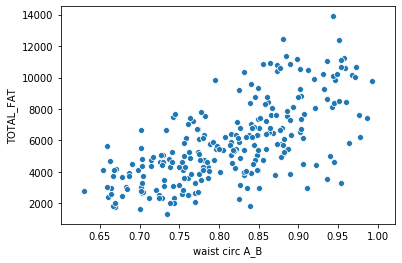

In [102]:
ax = sns.scatterplot(x="waist circ A_B", y="TOTAL_FAT", data=SUP4)

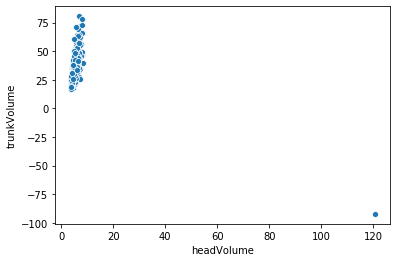

In [103]:
ax = sns.scatterplot(x="headVolume", y="trunkVolume", data=SUP4)

In [107]:
SUP4.drop([SUP4.headVolume.idxmax()],inplace=True)

/opt/anaconda3/lib/python3.7/site-packages/pandas/core/frame.py:4102: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  errors=errors,


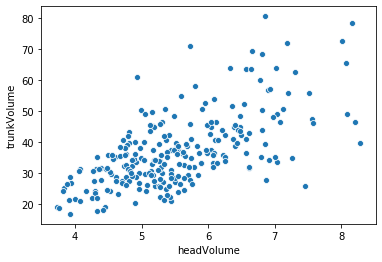

In [108]:
ax = sns.scatterplot(x="headVolume", y="trunkVolume", data=SUP4)

In [252]:
feat4=['BMI','age','race','TotalVolume', 'ArmVolume', 'LegVolume', 'headVolume', 'trunkVolume',
       'Chest circ', 'waist circ', 'hip circ', 'ThighGirth','CalfCirc', 'WristGirth',
       'ForearmGirth','BicepGirth', 'Ankle','ArmLength', 'CollarScalp', 'TrunkLength', 'LegLength',
       'crotchHeight', 'Chest circ A_B', 'waist circ A_B','hip circ A_B', 'ThighGirth A_B', 'CalfCirc A_B',
       'WristGirth A_B','ForearmGirth A_B', 'BicepGirth A_B', 'Ankle A_B',
       'SA_total', 'SA_Arm', 'SA_head', 'SA_Leg','SA_trunk']
X=SUP4[feat4]
y=SUP4['TOTAL_FAT']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)
print ('Train set:', X_train.shape,  y_train.shape)
print ('Test set:', X_test.shape,  y_test.shape)
X= preprocessing.StandardScaler().fit(X).transform(X)

Train set: (196, 36) (196,)
Test set: (50, 36) (50,)


In [253]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
clf = Ridge(alpha=1.0)
clf.fit(X_train, y_train)
yh=clf.predict(X_train)

print(r2_score(y_train,yh))
print(clf.score(X_train, y_train))


0.9308546187359129
0.9308546187359128


In [254]:
yhat=clf.predict(X_test)
print(r2_score(y_test,yhat))
print(clf.score(X_test, y_test))


0.8704315487497918
0.8704315487497918


In [256]:
from sklearn.model_selection import cross_val_score,cross_val_predict,cross_validate
 
#clf = Ridge(alpha=1.0)
clf = LinearRegression()
#scores = cross_val_score(clf, X, y, cv=5,r eturn_train_score=True)
scores = cross_validate(clf, X, y, cv=5,return_train_score=True)

#scores = cross_val_score(clf, X, y, cv=5,r eturn_train_score=True)
#print(scores)
print("Train Accuracy: %0.2f +/- %0.2f" % (scores['train_score'].mean(), scores['train_score'].std() * 2))
print("Test Accuracy: %0.2f +/- %0.2f" % (scores['test_score'].mean(), scores['test_score'].std() * 2))


Train Accuracy: 0.94 +/- 0.01
Test Accuracy: 0.89 +/- 0.05


In [257]:
from sklearn.linear_model import LinearRegression
LR = LinearRegression()
LR.fit(X_train, y_train)
yh=LR.predict(X_train)
print(r2_score(y_train,yh))
print(LR.score(X_train, y_train))
yhat=LR.predict(X_test)
print(r2_score(y_test,yhat))
print(LR.score(X_test, y_test))

0.9400469226668153
0.9400469226668152
0.8863482982837628
0.8863482982837629


In [258]:
scores = cross_validate(LR, X, y, cv=5,return_train_score=True)

print("Train Accuracy: %0.2f +/- %0.2f" % (scores['train_score'].mean(), scores['train_score'].std() * 2))
print("Test Accuracy: %0.2f +/- %0.2f" % (scores['test_score'].mean(), scores['test_score'].std() * 2))

Train Accuracy: 0.94 +/- 0.01
Test Accuracy: 0.89 +/- 0.05


In [259]:
from sklearn.neural_network import MLPRegressor
LR = MLPRegressor()
LR.fit(X_train, y_train)
yh=LR.predict(X_train)
print(r2_score(y_train,yh))
print(LR.score(X_train, y_train))
yhat=LR.predict(X_test)
print(r2_score(y_test,yhat))
print(LR.score(X_test, y_test))

0.24545401015760238
0.24545401015760238
0.1999542595113225
0.1999542595113225


In [261]:
SUP3=SUP2[feat2]
SUP3.drop([SUP3.headVolume.idxmax()],inplace=True)
SUP3.shape
feat2=['BMI','age','race','TotalVolume', 'rArmVolume','lArmVolume', 'rLegVolume', 'lLegVolume', 'headVolume', 'trunkVolume',
       'Chest circ', 'waist circ', 'hip circ', 'rThighGirth', 'lThighGirth',
       'rCalfCirc', 'lCalfCirc', 'rWristGirth', 'lWristGirth', 'rForearm',
       'lForearmGirth', 'rbicepGirth', 'lBicepGirth', 'rAnkle', 'Lankle',
       'LarmLength', 'RArmLength', 'CollarScalp', 'TrunkLength', 'lLegLength',
       'rLegLength', 'crotchHeight', 'Chest circ A_B', 'waist circ A_B',
       'hip circ A_B', 'rThighGirth A_B', 'lThighGirth A_B', 'rCalfCirc A_B',
       'lCalfCirc A_B', 'rWristGirth A_B', 'lWristGirth A_B', 'rForearm A_B',
       'lForearmGirth A_B', 'rbicepGirth A_B', 'lBicepGirth A_B', 'rAnkle A_B',
       'Lankle A_B', 'SA_total', 'SA_lArm', 'SA_rArm', 'SA_head', 'SA_lLeg',
       'SA_rLeg', 'SA_trunk']
X0=SUP3[feat2]
y0=SUP4['TOTAL_FAT']
X_train, X_test, y_train, y_test = train_test_split(X0, y0, test_size=0.2, random_state=2)
print ('Train set:', X_train.shape,  y_train.shape)
print ('Test set:', X_test.shape,  y_test.shape)
X0= preprocessing.StandardScaler().fit(X0).transform(X0)

Train set: (196, 54) (196,)
Test set: (50, 54) (50,)


In [262]:
from sklearn.linear_model import LinearRegression
LR = LinearRegression()
LR.fit(X_train, y_train)
yh=LR.predict(X_train)
print(r2_score(y_train,yh))
print(LR.score(X_train, y_train))
yhat=LR.predict(X_test)
print(r2_score(y_test,yhat))
print(LR.score(X_test, y_test))

0.94887446760856
0.9488744676085599
0.8808149784803537
0.8808149784803537


In [264]:
from sklearn.model_selection import cross_val_score,cross_val_predict,cross_validate
 
#clf = Ridge(alpha=1.0)
clf = LinearRegression()
scores = cross_validate(clf, X0, y0, cv=5,return_train_score=True)

print("Train Accuracy: %0.2f +/- %0.2f" % (scores['train_score'].mean(), scores['train_score'].std() * 2))
print("Test Accuracy: %0.2f +/- %0.2f" % (scores['test_score'].mean(), scores['test_score'].std() * 2))

Train Accuracy: 0.95 +/- 0.01
Test Accuracy: 0.87 +/- 0.05


In [265]:
SUP4.describe()

,TOTAL_FAT,BMI,age,race,TotalVolume,ArmVolume,LegVolume,headVolume,trunkVolume,Chest circ,...,CalfCirc A_B,WristGirth A_B,ForearmGirth A_B,BicepGirth A_B,Ankle A_B,SA_total,SA_Arm,SA_head,SA_Leg,SA_trunk
count,246.000000,246.000000,246.000000,246.000000,246.000000,246.000000,246.000000,246.000000,246.000000,246.000000,...,246.000000,246.000000,246.000000,246.000000,246.000000,246.000000,246.000000,246.000000,246.000000,246.000000
mean,5847.579009,27.302573,48.296748,2.215447,66.893400,2.769888,9.378955,5.542811,37.052903,95.935115,...,0.897502,0.725640,0.816976,0.846058,0.656654,6228.659929,559.664393,688.405025,2427.153488,2067.542247
std,2562.671644,6.939305,17.218563,1.572183,16.870922,0.860367,2.111304,0.954869,11.653247,11.021072,...,0.035361,0.072718,0.045451,0.067648,0.061548,788.271961,97.730115,80.167330,294.862767,350.299741
min,1322.552855,14.162487,20.000000,0.000000,33.709080,1.346116,4.706009,3.723340,16.916026,72.551837,...,0.791498,0.437812,0.683898,0.574605,0.447764,4547.699488,360.117745,533.985808,1680.876268,1405.752362
25%,3982.072778,22.732504,32.000000,1.000000,55.367197,2.121813,8.071405,4.854334,29.183104,88.219879,...,0.876158,0.686369,0.786001,0.805951,0.612782,5676.288648,483.084192,632.748836,2223.889442,1835.119308
50%,5437.520912,26.294448,49.000000,2.000000,65.397616,2.625338,9.147913,5.411019,35.079315,94.927463,...,0.899388,0.728331,0.815062,0.857210,0.651426,6185.069701,539.335738,680.157785,2437.691281,2010.520822
75%,7397.728001,30.424129,64.000000,4.000000,75.977914,3.294882,10.650877,6.115670,42.562693,102.531978,...,0.923902,0.768759,0.850651,0.898071,0.694708,6710.520411,627.681177,733.607216,2626.505680,2259.560390
max,13890.678810,71.162221,81.000000,4.000000,127.619333,6.340416,18.079773,8.281334,80.497417,130.232213,...,0.962880,0.913480,0.925414,0.957125,0.900488,8581.055659,854.025028,954.955087,3498.938853,3315.461792
